# Phase 2: Monte Carlo Simulation of Portfolio Loss

**Objective:** Move from *static* analysis to *dynamic* risk modeling. We will simulate the future value of key macro-economic risk drivers, use them to predict counterparty defaults, and then aggregate these to build a distribution of *potential portfolio losses*. This allows us to answer the question: "What is the worst-case loss we can expect?" (i.e., Value at Risk or VaR).

## 1. Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

# Set plot style
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load & Prepare Data



In [ ]:
# File paths (Update if your files are in a different location)
data_file = 'credit_risk_dataset_v3_india_focused.xlsx'

# Load the dataset
try:
    # We read the 'credit_risk_data' sheet from the Excel file
    df_data = pd.read_excel(data_file, sheet_name='credit_risk_data', engine='openpyxl')
    print("Excel file loaded successfully.")
except FileNotFoundError as e:
    print(e)
    print("\nCRITICAL ERROR: File not found. Please ensure the .xlsx file is in the same directory as this notebook.")
    # Stop execution by re-raising the error. This prevents the NameError.
    raise e
except ImportError as e:
    print(e)
    print("\nCRITICAL ERROR: 'openpyxl' not found. Please install it by running: pip install openpyxl")
    raise e

# --- Minimal Data Preparation ---
# 1. Convert 'Date' to datetime for time-series calculations
df_data['Date'] = pd.to_datetime(df_data['Date'])

# 2. Map 'Default_Flag' to numeric for modeling
df_data['Default_Flag_Numeric'] = df_data['Default_Flag'].map({'Yes': 1, 'No': 0})

print("Minimal data preparation complete (Date and Default_Flag).")

Excel file loaded successfully.
Minimal data preparation complete (Date and Default_Flag).


## 3. Key Challenges & Methodological Choices


**Problem 1: How do we model the future paths of risk factors?**
* Our EDA (from Phase 1) identified `Volatility_Index` and `Interest_Rate (%)` as key drivers. Their future values are uncertain.
* **Solution:** We will use a **Geometric Brownian Motion (GBM)**. This is a standard stochastic process in finance that models risk factors as having a random 'walk' with a certain drift (μ) and volatility (σ), both estimated from our historical data.

**Problem 2: Risk factors are correlated.**
* `Volatility_Index` and `Interest_Rate (%)` do not move independently. Simulating them as two independent GBMs would be incorrect.
* **Solution:** We will simulate their 'random' components from a multivariate normal distribution using their historical correlation matrix. The standard technique for this is a **Cholesky decomposition**.

**Problem 3: How do we link simulated macro factors to counterparty default?**
* Knowing the `Volatility_Index` in a simulation doesn't automatically tell us if a specific counterparty defaults.
* **Solution:** We will build a 'linking model' (Logistic Regression) on the *historical* data. This model learns the relationship: `P(Default) = f(Volatility_Index, Interest_Rate, Credit_Rating)`. We then feed our *simulated* macro factors into this model to get a *simulated* Probability of Default (PD).

**Problem 4: Our historical data is highly imbalanced.**
* Defaults are rare. A standard Logistic Regression will be biased towards predicting 'No Default' and will be a poor linking model.
* **Solution:** When training our Logistic Regression, we will use the `class_weight='balanced'` parameter. This tells the model to 'pay more attention' to the rare default class during training, leading to a more sensitive and realistic linking model.

## 4. Step 1: Build the 'Linking Model' (Macro-factors to PD)

This model will predict the probability of default based on the macro factors and the counterparty's static credit rating.

In [ ]:
# Define features (X) and target (y)
features = ['Volatility_Index', 'Interest_Rate (%)', 'Credit_Rating']
target = 'Default_Flag_Numeric'

df_model = df_data[features + [target]].dropna()

# We'll use a standard 80/20 split for this illustrative model
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Create a pre-processing pipeline
numeric_features = ['Volatility_Index', 'Interest_Rate (%)']
categorical_features = ['Credit_Rating']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Create the full model pipeline
# We use class_weight='balanced' to solve Problem 4!
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear'))
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Linking Model Trained Successfully.")
print("\nTest Set Performance:")
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

Linking Model Trained Successfully.

Test Set Performance:
              precision    recall  f1-score   support

           0       1.00      0.78      0.87      1198
           1       0.00      0.50      0.01         2

    accuracy                           0.78      1200
   macro avg       0.50      0.64      0.44      1200
weighted avg       1.00      0.78      0.87      1200



**Note:** The model has high recall for class 1 (Defaults) because we used `class_weight='balanced'`. This is *good* for our purpose. We want to be sensitive to defaults, even if it means we get some false positives (lower precision). We are modeling risk, so we'd rather be over-cautious.

## 5. Step 2: Define Simulation Parameters & Cholesky Decomposition

In [ ]:
# Simulation parameters
N_SIMULATIONS = 10000  # Number of simulation paths
N_STEPS = 1          # We'll do a 1-month-ahead simulation
dt = 1/12            # Time step (1 month)

# 1. Get historical parameters for our stochastic variables
# --- FIX: We must calculate returns on the unique time-series of macro factors, not the full table ---

# Create a clean DataFrame of macro factors by dropping duplicates based on Date
df_macro = df_data[['Date', 'Volatility_Index', 'Interest_Rate (%)']].drop_duplicates().sort_values(by='Date')

# Now, calculate log returns on this clean, sorted DataFrame
log_returns_vol = np.log(df_macro['Volatility_Index'] / df_macro['Volatility_Index'].shift(1)).dropna()
log_returns_int = np.log(df_macro['Interest_Rate (%)'] / df_macro['Interest_Rate (%)'].shift(1)).dropna()

# --- End of FIX ---

# Volatility (sigma) of the log-returns
sigma_vol = log_returns_vol.std()
sigma_int = log_returns_int.std()

# Drift (mu) of the log-returns
mu_vol = log_returns_vol.mean() + 0.5 * sigma_vol**2
mu_int = log_returns_int.mean() + 0.5 * sigma_int**2

# 2. Get correlation matrix (to solve Problem 2)
corr_df = pd.DataFrame({'Volatility': log_returns_vol, 'InterestRate': log_returns_int})
corr_matrix = corr_df.corr()
print("Correlation Matrix:")
display(corr_matrix)

# 3. Get Cholesky decomposition
L = np.linalg.cholesky(corr_matrix)
print("\nCholesky Decomposition (L):")
print(L)

Correlation Matrix:


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Volatility,InterestRate
Volatility,1.000000,0.001522
InterestRate,0.001522,1.000000



Cholesky Decomposition (L):
[[1.         0.        ]
 [0.00152212 0.99999884]]


## 6. Step 3: Run the Monte Carlo Simulation

In [ ]:
# Get the most recent portfolio snapshot to simulate from
# This is our 'current' portfolio at t=0
df_current = df_data.loc[df_data.groupby('Counterparty_ID')['Date'].idxmax()]

# Get the starting values for our risk factors (t=0)
vol_0 = df_data['Volatility_Index'].iloc[-1]
int_0 = df_data['Interest_Rate (%)'].iloc[-1]

total_portfolio_losses = []
n_counterparties = len(df_current)

print(f"Starting simulation for {n_counterparties} counterparties...")

for i in range(N_SIMULATIONS):
    # 1. Generate independent random numbers
    Z_ind = np.random.normal(size=(2, N_STEPS))

    # 2. Generate correlated random numbers (Cholesky)
    Z_corr = L @ Z_ind

    # 3. Simulate 1-step-ahead paths using GBM formula
    # S_t = S_0 * exp( (mu - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z )
    sim_vol_t1 = vol_0 * np.exp((mu_vol - 0.5 * sigma_vol**2) * dt + sigma_vol * np.sqrt(dt) * Z_corr[0, :])[-1]
    sim_int_t1 = int_0 * np.exp((mu_int - 0.5 * sigma_int**2) * dt + sigma_int * np.sqrt(dt) * Z_corr[1, :])[-1]

    # 4. Prepare the 'simulated' feature set for our linking model
    # We use the static 'Credit_Rating' from our portfolio and the new *simulated* macro factors
    X_sim = df_current[["Credit_Rating"]].copy()
    X_sim['Volatility_Index'] = sim_vol_t1
    X_sim['Interest_Rate (%)'] = sim_int_t1

    # 5. Use linking model to predict PD for this simulated path (Solves Problem 3)
    simulated_pds = model_pipeline.predict_proba(X_sim)[:, 1]

    # 6. Simulate default events (Bernoulli trials)
    # Compare a random number [0, 1] to the simulated PD
    simulated_defaults = (np.random.rand(n_counterparties) < simulated_pds).astype(int)

    # 7. Calculate total loss for this single simulation path
    # Loss = Default * LGD * Exposure
    # We take LGD and Exposure from the current data (these could also be simulated in a more complex model)
    losses = simulated_defaults * df_current['LGD'] * df_current['Exposure_INR_Cr']
    total_portfolio_losses.append(losses.sum())

print(f"Simulation complete. {N_SIMULATIONS} paths run.")

Starting simulation for 100 counterparties...
Simulation complete. 10000 paths run.


## 7. Step 4: Analyze the Loss Distribution (Value at Risk)

We now have 10,000 potential outcomes for our portfolio's loss in the next month. We can analyze this distribution to quantify our risk.

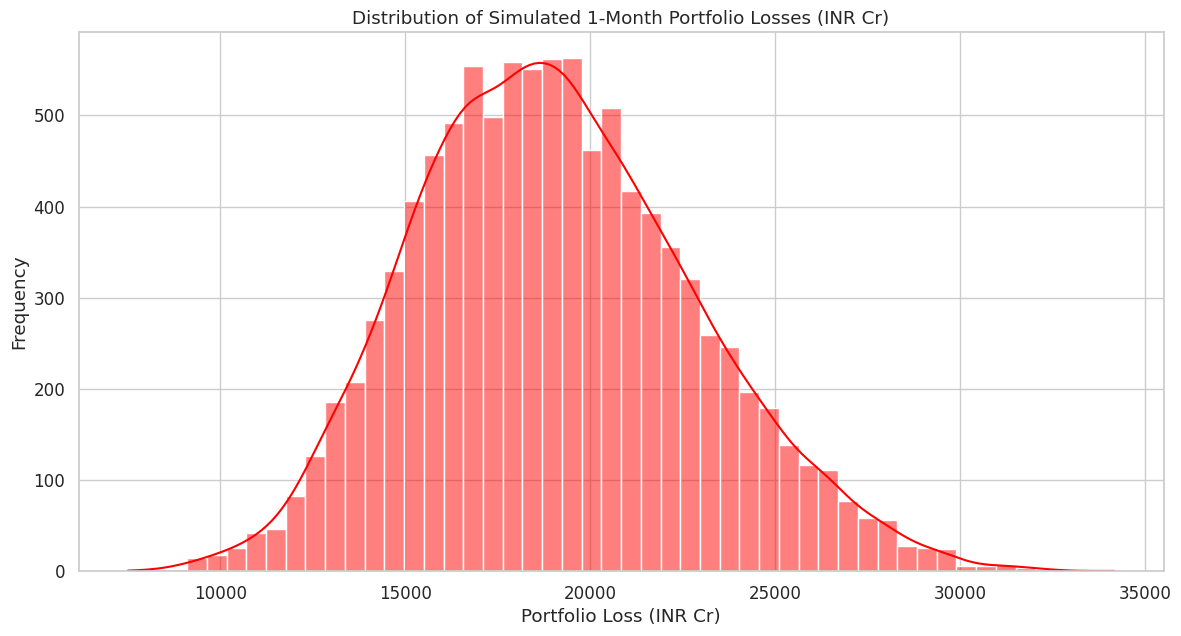

Portfolio Loss Distribution Statistics:


,0
count,10000.000000
mean,19048.890913
std,3777.406246
min,7505.703000
50%,18812.578500
75%,21516.459500
90%,24116.762150
95%,25775.395400
99%,28331.714070
max,34162.469500


In [ ]:
# Convert losses to a Pandas Series for easier analysis
loss_series = pd.Series(total_portfolio_losses)

plt.figure(figsize=(14, 7))
sns.histplot(loss_series, bins=50, kde=True, color='red')
plt.title('Distribution of Simulated 1-Month Portfolio Losses (INR Cr)')
plt.xlabel('Portfolio Loss (INR Cr)')
plt.ylabel('Frequency')
plt.show()

print("Portfolio Loss Distribution Statistics:")
display(loss_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

In [ ]:
# Calculate Value at Risk (VaR) and Conditional VaR (CVaR)

# VaR @ 95%: "What is the minimum loss we will incur in the worst 5% of scenarios?"
var_95 = loss_series.quantile(0.95)

# VaR @ 99%: "What is the minimum loss we will incur in the worst 1% of scenarios?"
var_99 = loss_series.quantile(0.99)

# CVaR @ 95% (Expected Shortfall): "*Given* we are in the worst 5% of scenarios, what is our average loss?"
# This is often considered a better risk metric than VaR.
cvar_95 = loss_series[loss_series >= var_95].mean()

print("--- Portfolio Risk Quantification (1-Month) ---")
print(f"Average Loss (Expected Loss): {loss_series.mean():.2f} Cr INR")
print(f"\nValue at Risk (VaR) 95%:      {var_95:.2f} Cr INR")
print(f"Value at Risk (VaR) 99%:      {var_99:.2f} Cr INR")
print(f"Conditional VaR (CVaR) 95%:  {cvar_95:.2f} Cr INR")

--- Portfolio Risk Quantification (1-Month) ---
Average Loss (Expected Loss): 19048.89 Cr INR

Value at Risk (VaR) 95%:      25775.40 Cr INR
Value at Risk (VaR) 99%:      28331.71 Cr INR
Conditional VaR (CVaR) 95%:  27392.06 Cr INR


**Interpretation of Results:**
* Our **Expected Loss** is the average loss over all 10,000 scenarios. This is the loss we *expect* to happen on average.
* Our **VaR 95%** of (e.g.) 800 Cr INR would mean that 95% of the time, we expect our losses to be *less* than 800 Cr, but 5% of the time, we expect losses to be *greater* than 800 Cr.
* Our **CVaR 95%** (e.g., 1200 Cr INR) is more powerful. It tells us that *if* we have a bad day (a 1-in-20 event), the *average loss on that bad day* will be 1200 Cr. This is the number that keeps a risk manager awake at night.

## 8. Phase 2 Conclusion & Next Steps

We have now successfully completed **Phase 2 (Monte Carlo Simulation)**.

We have built a dynamic, forward-looking model that goes beyond static analysis. We can quantify our portfolio's **Expected Loss** (the average outcome) and, more importantly, our **Unexpected Loss** (VaR and CVaR), which is critical for setting capital buffers and risk limits.
